# FinBERT Demo: Confusion Matrix

This notebook loads `results.json` produced by `pipelines/finbert_pipeline/finbert_pipeline.py` (or `analysis/demo.py`) and plots a confusion matrix for a chosen model.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configure these ---
REPO_ROOT = Path.cwd()
SUBSET = "sentences_75agree"  # e.g. sentences_50agree / sentences_66agree / sentences_75agree / sentences_allagree
RESULTS_BASE = REPO_ROOT / "pipelines" / "finbert_pipeline" / "results"

results_dir = RESULTS_BASE / SUBSET
results_path = results_dir / "results.json"

if not results_path.exists():
    raise FileNotFoundError(
        f"Missing {results_path}. Run: python pipelines/finbert_pipeline/finbert_pipeline.py --subset {SUBSET}"
    )

with results_path.open("r", encoding="utf-8") as f:
    results = json.load(f)

model_names = [m.get("name", "unknown") for m in results.get("models", [])]
model_names

['logistic_regression', 'linear_svm', 'xgboost']

,negative,neutral,positive
negative,80,2,2
neutral,1,421,7
positive,3,7,168


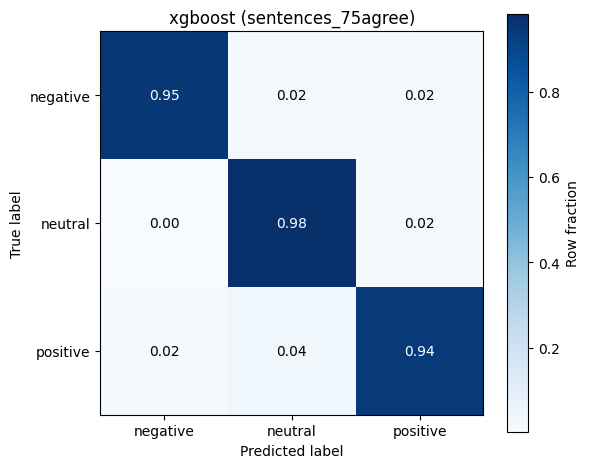

In [5]:
MODEL ='xgboost'
NORMALIZE = True  # normalize rows to percentages


def _label_names_from_report(report: dict) -> list[str]:
    if not isinstance(report, dict):
        return []
    skip = {"accuracy", "macro avg", "weighted avg", "micro avg", "samples avg"}
    labels: list[str] = []
    for k, v in report.items():
        if k in skip:
            continue
        if isinstance(v, dict):
            labels.append(str(k))
    return labels


def plot_confusion_matrix(cm: np.ndarray, labels: list[str], normalize: bool = False, title: str = "Confusion Matrix"):
    cm = np.asarray(cm)
    if normalize:
        denom = cm.sum(axis=1, keepdims=True)
        denom = np.where(denom == 0, 1, denom)
        cm_plot = cm / denom
        fmt = ".2f"
        cbar_label = "Row fraction"
    else:
        cm_plot = cm
        fmt = "d"
        cbar_label = "Count"

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_plot, interpolation="nearest", cmap=plt.cm.Blues)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    ax.set(
        title=title,
        ylabel="True label",
        xlabel="Predicted label",
    )

    if labels:
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=0, ha="center")
        ax.set_yticklabels(labels)

    thresh = cm_plot.max() / 2.0 if cm_plot.size else 0
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            val = cm_plot[i, j]
            ax.text(
                j,
                i,
                format(val, fmt),
                ha="center",
                va="center",
                color="white" if val > thresh else "black",
            )

    fig.tight_layout()
    return fig, ax


if MODEL is None:
    raise ValueError("No models found in results.json")

model_entry = next((m for m in results.get("models", []) if m.get("name") == MODEL), None)
if model_entry is None:
    raise ValueError(f"Model {MODEL!r} not found. Available: {model_names}")

metrics = model_entry.get("metrics", {}) or {}
cm = metrics.get("confusion_matrix")
if cm is None:
    raise ValueError("No confusion_matrix found in results.json")

labels = _label_names_from_report(metrics.get("classification_report", {}))
cm_np = np.array(cm)
display(pd.DataFrame(cm_np, index=labels or None, columns=labels or None))

plot_confusion_matrix(cm_np, labels, normalize=NORMALIZE, title=f"{MODEL} ({SUBSET})")
plt.show()